In [39]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

from pydrake.geometry.optimization import HPolyhedron
from pydrake.solvers import MosekSolver

from gcs.bezier import BezierGCS
from gcs.linear import LinearGCS
from gcs.multipleShooting import MultipleShootingGCS
from models.env_2d import obstacles, vertices

import time

savefig = 0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Environment setup

In [2]:
x_start = np.array([.2, .2])
x_goal = np.array([4.8, 4.8])

x_min = np.min(np.vstack(vertices), axis=0)
x_max = np.max(np.vstack(vertices), axis=0)

def make_hpolytope(V):
    ch = ConvexHull(V)
    return HPolyhedron(ch.equations[:, :-1], - ch.equations[:, -1])

regions = [make_hpolytope(V) for V in vertices]

def environment_setup():
    
    plt.figure(figsize=(3, 3))
    plt.axis('square')
    
    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    
    tick_gap = .2
    n_ticks = lambda x_min, x_max: round((x_max - x_min) / tick_gap) + 1
    x_ticks = np.linspace(x_min[0], x_max[0], n_ticks(x_min[0], x_max[0]))
    y_ticks = np.linspace(x_min[1], x_max[1], n_ticks(x_min[1], x_max[1]))
    plt.xticks(x_ticks)
    plt.yticks(y_ticks)
    
    label_gap = .5
    keep_label = lambda t: np.isclose(t % label_gap, 0) or np.isclose(t % label_gap, label_gap)
    x_labels = [int(t) if keep_label(t) else '' for t in x_ticks]
    y_labels = [int(t) if keep_label(t) else '' for t in y_ticks]
    plt.gca().set_xticklabels(x_labels)
    plt.gca().set_yticklabels(y_labels)
    
    plt.grid()

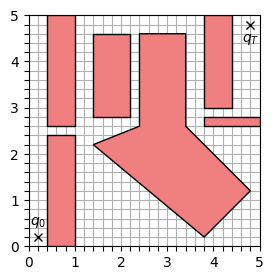

In [3]:
environment_setup()

for O in obstacles:
    plt.fill(*O.T, fc='lightcoral', ec='k', zorder=4)

plt.plot(*x_start, 'kx')
plt.plot(*x_goal, 'kx')

plt.text(.2, .35, '$q_0$', ha='center', va='bottom')
plt.text(4.8, 4.65, '$q_T$', ha='center', va='top')

if savefig:
    plt.savefig('setup.pdf', bbox_inches='tight')

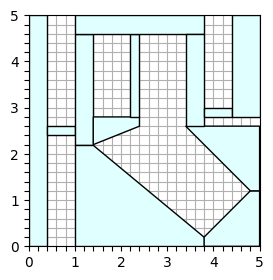

In [4]:
environment_setup()

for V in vertices:
    plt.fill(*V.T, fc='lightcyan', ec='k', zorder=4)

if savefig:
    plt.savefig('decomposition.pdf', bbox_inches='tight')

# Minimum-distance problem

In [5]:
def plot_trajectory(waypoints):

    plt.figure(figsize=(3, 3))

    for O in obstacles:
        plt.fill(*O.T, fc='lightcoral', ec='k', zorder=4)

    plt.plot(*x_start, 'kx')
    plt.plot(*x_goal, 'kx')
    plt.plot(*waypoints, 'b', zorder=5)

    plt.axis('square')
    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    plt.xticks(range(6))
    plt.yticks(range(6))
    plt.grid(1)

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.


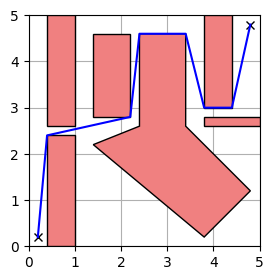

In [6]:
relaxation = True
gcs = LinearGCS(regions)
gcs.addSourceTarget(x_start, x_goal)
gcs.setSolver(MosekSolver())
waypoints = gcs.SolvePath(relaxation)[0]
plot_trajectory(waypoints)
if savefig:
    plt.savefig('linear.pdf', bbox_inches='tight')

# Minimum-time problem

In [7]:
qdot_min = -1
qdot_max = 1
n_samples = 500

def solve_bezier(order, continuity, regularizer=None, hdot_min=1e-6, velocity=None):
    
    gcs = BezierGCS(regions, order, continuity, hdot_min=hdot_min)

    gcs.addTimeCost(1)
    gcs.addVelocityLimits([qdot_min] * 2, [qdot_max] * 2)
    if regularizer is not None:
        gcs.addDerivativeRegularization(*regularizer, 2)
    gcs.addSourceTarget(x_start, x_goal, velocity=velocity)
    
    gcs.setSolver(MosekSolver())
    gcs.setPaperSolverOptions()
    
    traj = gcs.SolvePath(relaxation)[0]
    times = np.linspace(traj.start_time(), traj.end_time(), n_samples)
    waypoints = np.squeeze([traj.value(t) for t in times]).T
    velocities = np.squeeze([traj.EvalDerivative(t) for t in times]).T

    return waypoints, velocities, times

In [8]:
def plot_velocity(velocities, times, tol=np.inf):
    
    def plot_with_jumps(velocities, color):
        for i in range(len(times) - 1):
            dv = velocities[i + 1] - velocities[i]
            style = '-' if abs(dv) < tol else ':'
            plt.plot(times[i:i+2], velocities[i:i+2], color=color, linestyle=style)
            
    plt.figure(figsize=(3, 2))
            
    plot_with_jumps(velocities[0], 'tab:blue')
    plot_with_jumps(velocities[1], 'tab:orange')

    plt.xlim([times[0], times[-1]])
    plt.xticks(np.arange(int(np.ceil(times[-1] / 2))) * 2)
    plt.yticks(np.linspace(qdot_min, qdot_max, 5))
    plt.xlabel('Time $t$')
    plt.ylabel('Velocity $\dot{q}$')
    plt.grid()

<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_68979/3165938659.py:18: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('Velocity $\dot{q}$')


INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1541            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 411             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 295
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 21
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes   

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 3 unique paths, discarded 97 duplicate paths.
INFO:drake:Finished 3 rounding solutions with MOSEK.


10  1.2e-03  1.2e-03  2.3e-04  1.01e+00   9.874800336e+00   9.878318334e+00   1.8e-07  0.08  
11  2.3e-05  2.3e-05  4.5e-06  1.00e+00   9.879887806e+00   9.879955202e+00   3.5e-09  0.09  
12  1.3e-06  1.3e-06  2.5e-07  9.98e-01   9.879993787e+00   9.879997517e+00   1.9e-10  0.09  
13  1.3e-07  1.2e-07  2.3e-08  1.00e+00   9.879999607e+00   9.879999952e+00   1.8e-11  0.10  
14  2.9e-08  2.3e-08  4.4e-09  1.00e+00   9.879999925e+00   9.879999991e+00   3.4e-12  0.11  
15  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.11  
16  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.12  
Basis identification started.
Basis identification initialization started.
Basis identification initialization terminated. Time: 0.00
Primal basis identification phase started.
Primal basis identification phase terminated. Time: 0.00
Dual basis identification phase started.
Dual basis identification phase terminated. Time: 0.00
Initializati

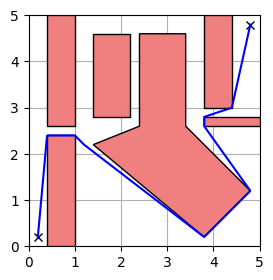

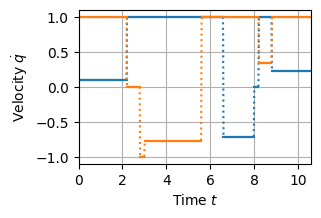

In [9]:
order = 1
continuity = 0
waypoints, velocities, times = solve_bezier(order, continuity)

plot_trajectory(waypoints)
if savefig:
    plt.savefig('bezier_10.pdf', bbox_inches='tight')

plot_velocity(velocities, times, tol=1e-1)
if savefig:
    plt.savefig('bezier_10_vel.pdf', bbox_inches='tight')

Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 5558            
  Affine conic cons.     : 290 (1015 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 1571            
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 946
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 123
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes 

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


35  3.7e-05  2.2e-04  4.3e-06  7.02e-01   2.720600794e+01   2.717936977e+01   3.7e-08  1.27  
36  2.3e-05  1.4e-04  2.3e-06  8.06e-01   2.723169649e+01   2.721411292e+01   2.3e-08  1.31  
37  7.3e-06  4.4e-05  4.4e-07  8.83e-01   2.726598583e+01   2.726020075e+01   7.4e-09  1.34  
38  4.7e-06  2.8e-05  2.3e-07  9.53e-01   2.727308040e+01   2.726933558e+01   4.7e-09  1.37  
39  1.4e-06  8.1e-06  3.8e-08  9.69e-01   2.728267021e+01   2.728157810e+01   1.4e-09  1.40  
40  1.8e-07  1.1e-06  2.0e-09  9.91e-01   2.728655224e+01   2.728640425e+01   1.8e-10  1.43  
41  5.5e-08  1.4e-07  7.7e-11  1.00e+00   2.728716364e+01   2.728714675e+01   2.1e-11  1.47  
Optimizer terminated. Time: 1.47    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.7287163638e+01    nrm: 1e+03    Viol.  con: 2e-04    var: 0e+00    acc: 1e-05  
  Dual.    obj: 2.7287159279e+01    nrm: 2e+11    Viol.  con: 9e-09    var: 1e-04    acc: 0e+00  
Pr

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 4 unique paths, discarded 96 duplicate paths.


36  2.3e-05  1.4e-04  2.3e-06  8.06e-01   2.723169649e+01   2.721411292e+01   2.3e-08  1.24  
37  7.3e-06  4.4e-05  4.4e-07  8.83e-01   2.726598583e+01   2.726020075e+01   7.4e-09  1.27  
38  4.7e-06  2.8e-05  2.3e-07  9.53e-01   2.727308040e+01   2.726933558e+01   4.7e-09  1.30  
39  1.4e-06  8.1e-06  3.8e-08  9.69e-01   2.728267021e+01   2.728157810e+01   1.4e-09  1.33  
40  1.8e-07  1.1e-06  2.0e-09  9.91e-01   2.728655224e+01   2.728640425e+01   1.8e-10  1.36  
41  5.5e-08  1.4e-07  7.7e-11  1.00e+00   2.728716364e+01   2.728714675e+01   2.1e-11  1.39  
Optimizer terminated. Time: 1.39    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.7287163638e+01    nrm: 1e+03    Viol.  con: 2e-04    var: 0e+00    acc: 1e-05  
  Dual.    obj: 2.7287159279e+01    nrm: 2e+11    Viol.  con: 9e-09    var: 1e-04    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        


INFO:drake:Finished 4 rounding solutions with MOSEK.


5   1.9e+01  9.3e-03  1.8e-01  -5.20e-01  5.724279464e+02   6.009240335e+02   1.9e-02  0.04  
8   3.6e+00  1.8e-03  9.5e-03  1.45e+00   2.457689652e+02   2.477482402e+02   3.6e-03  0.05  
5   1.8e+01  8.9e-03  1.8e-01  -5.20e-01  5.631227507e+02   5.943434386e+02   1.8e-02  0.05  
10  2.5e-01  1.3e-04  1.6e-04  1.06e+00   3.804922400e+01   3.816504178e+01   2.5e-04  0.05  
6   1.4e+01  6.9e-03  1.1e-01  2.33e-01   5.786708314e+02   5.988041789e+02   1.4e-02  0.05  
9   7.9e-01  4.0e-04  8.2e-04  1.57e+00   5.981831417e+01   6.013090545e+01   7.9e-04  0.05  
11  1.4e-01  7.2e-05  7.1e-05  1.04e+00   3.495468002e+01   3.502398328e+01   1.4e-04  0.05  
6   1.3e+01  6.5e-03  1.1e-01  2.24e-01   5.584194217e+02   5.801511253e+02   1.3e-02  0.05  
12  5.6e-02  2.8e-05  1.7e-05  1.03e+00   3.193583751e+01   3.196366744e+01   5.6e-05  0.06  
10  3.7e-01  1.8e-04  2.6e-04  1.17e+00   3.779234737e+01   3.793259174e+01   3.7e-04  0.05  
7   7.3e+00  3.7e-03  3.3e-02  6.90e-01   4.567506745e+02   

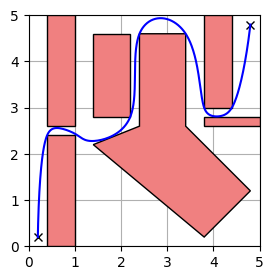

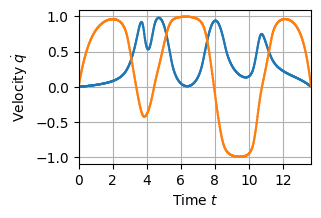

In [41]:
order = 6
continuity = 2
velocity = np.zeros((2, 2))
regularizer = [1e-1, 1e-1]
hdot_min = 1e-1
times_start = time.time()
waypoints, velocities, times = solve_bezier(order, continuity, regularizer, hdot_min, velocity=velocity)
times_end = time.time()
print(f"Solved in {times_end - times_start:.2f} seconds.")
plot_trajectory(waypoints)
if savefig:
    plt.savefig('bezier_62.pdf', bbox_inches='tight')

plot_velocity(velocities, times)
if savefig:
    plt.savefig('bezier_62_vel.pdf', bbox_inches='tight')

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 589             
  Affine conic cons.     : 29 (87 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 179             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 140
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 15
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes     

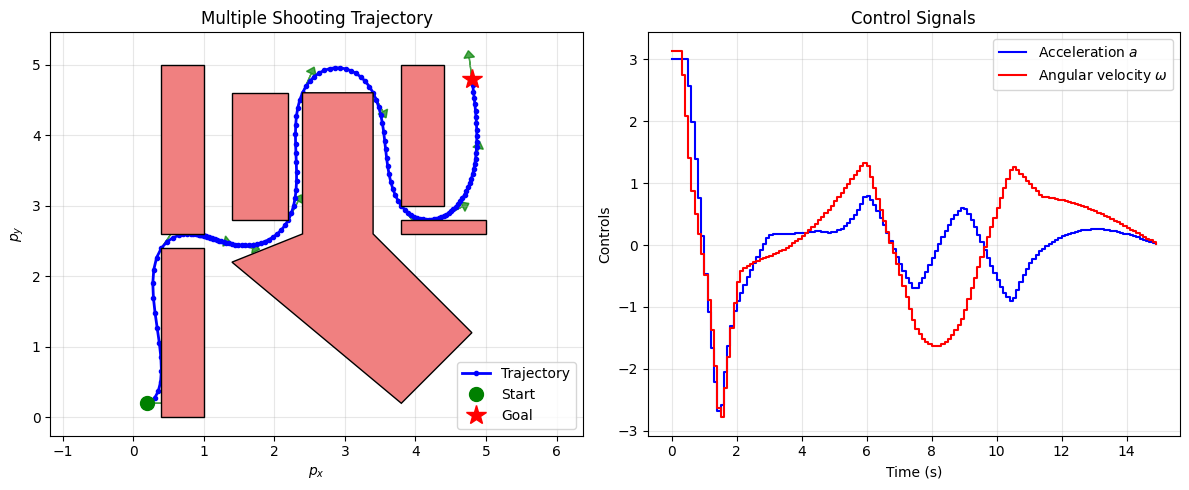

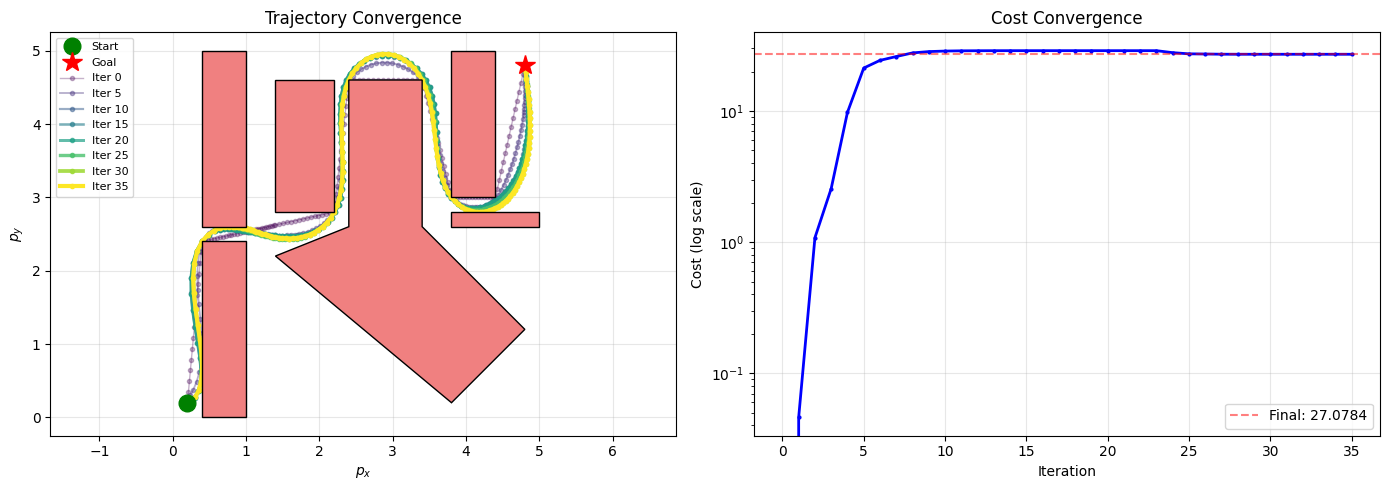

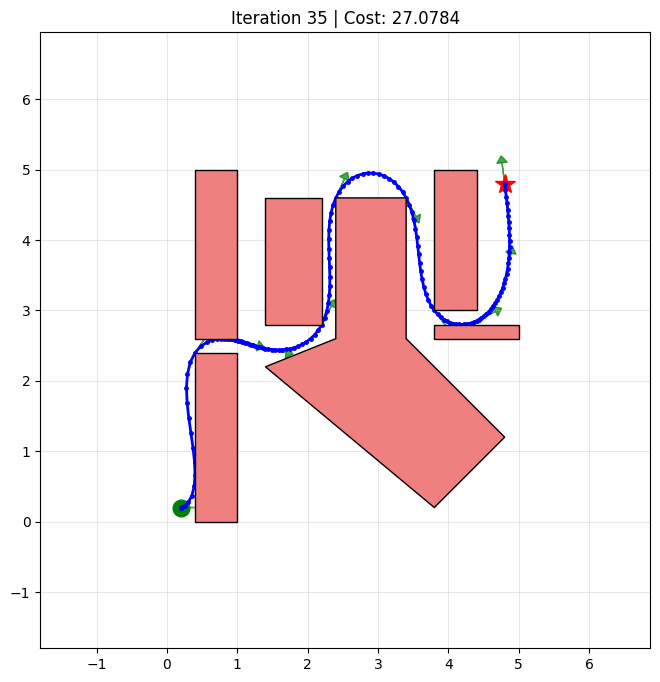

In [ ]:
def solve_multiple_shooting():
    
    gcs = MultipleShootingGCS(regions)

    # gcs.addTimeCost(1)
    # gcs.addLimitControl({'a_max': 3.0, 'omega_max': np.pi})
    gcs.addSourceTarget(x_start, x_goal)
    
    gcs.setSolver(MosekSolver())
    gcs.setPaperSolverOptions()
    
    # Truyền obstacles vào SolvePath để visualize
    start_time = time.time()
    traj, result = gcs.SolvePath(relaxation)
    end_time = time.time()
    print(f"Multiple Shooting solve time: {end_time - start_time} seconds")

    x_start_4d = np.array([x_start[0], x_start[1], 0.0, 0.0])
    x_goal_4d = np.array([x_goal[0], x_goal[1], 0.0, 0.0])

    # Visualize với iteration history
    if traj is not None and 'iteration_history' in traj and len(traj['iteration_history']) > 1:
        gcs.visualize_ms_result(traj, x_start_4d, x_goal_4d, 
                            obstacles=obstacles, 
                            iteration_history=traj['iteration_history'],
                            save_path='ms_gcs_result', 
                            show=False)
   
    return traj, result

traj, result = solve_multiple_shooting()